# Diabetic Retinopathy Analysis (Paper 2)
Implementation of the scientific paper: **"A multimodal retinal image dataset for diabetic retinopathy detection using foundation models"**.

In [ ]:
# CELL 1: Imports & Setup
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import zipfile
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### Splitting Data for Train and Test

In [4]:
import pandas as pd
import os

# Base folder where your data is stored
base_path = 'MMRDR'

# The three metadata files specified in the paper [cite: 261]
files = {
    'CFP': os.path.join(base_path, 'MMRDR-CFP', 'FP.csv'),
    'OCT': os.path.join(base_path, 'MMRDR-OCT', 'OCT.csv'),
    'UWF': os.path.join(base_path, 'MMRDR-UWF', 'UWF.csv')
}

print("--- MMRDR Dataset Column Names ---")

for modality, file_path in files.items():
    if os.path.exists(file_path):
        # Load only the header to save time
        df = pd.read_csv(file_path, nrows=0)
        print(f"\n{modality} Columns ({os.path.basename(file_path)}):")
        print(df.columns.tolist())
    else:
        print(f"\n{modality}: File not found at {file_path}")

--- MMRDR Dataset Column Names ---

CFP Columns (FP.csv):
['type', 'image', 'grade', 'lesion', 'lr']

OCT Columns (OCT.csv):
['type', 'image', 'grade', 'lesion', 'lr']

UWF Columns (UWF.csv):
['type', 'image', 'grade', 'lesion', 'lr']


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

def execute_mmrdr_split(base_path):
    # Paths based on the paper's organization [cite: 260]
    paths = {
        'cfp': os.path.join(base_path, 'MMRDR-CFP', 'FP.csv'),
        'uwf': os.path.join(base_path, 'MMRDR-UWF', 'UWF.csv'),
        'oct': os.path.join(base_path, 'MMRDR-OCT', 'OCT.csv')
    }
    
    data_splits = {}

    for modality, file_path in paths.items():
        if os.path.exists(file_path):
            # Load the CSV containing 'image', 'grade', 'lesion', and 'lr' [cite: 266, 268]
            df = pd.read_csv(file_path)
            
            # Split into 80% training and 20% testing 
            train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
            
            data_splits[f'{modality}_train'] = train_df
            data_splits[f'{modality}_test'] = test_df
        else:
            print(f"Warning: {file_path} not found.")
            
    return data_splits

# Run the split
splits = execute_mmrdr_split('MMRDR')

# Quick check of your new datasets
if splits:
    print(f"CFP Training Images: {len(splits['cfp_train'])}")
    print(f"UWF Training Images: {len(splits['uwf_train'])}")
    print(f"OCT Training Images: {len(splits['oct_train'])}")

CFP Training Images: 8894
UWF Training Images: 8323
OCT Training Images: 2350


### Model Training

Scale: 11,118 images in total.

Resolution:  512 X 512 pixels; anything smaller might lose the fine-grained lesion details like microaneurysms.

Target:  benchmark for ResNet-50 is an accuracy of $0.823$.

Labels: The model will classify images into 5 grades of severity (0 = No DR, up to 4 = PDR)

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
from tqdm import tqdm

# 1. Dataset Class
# MMRDR-CFP requires images to be processed from the OIA-DDR source[cite: 166].
class MMRDRDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Images are stored in JPEG format within an 'img' folder[cite: 261, 340].
        img_name = os.path.join(self.img_dir, self.df.iloc[idx]['image'])
        image = Image.open(img_name).convert('RGB')
        
        # DR severity is categorized into 5 grades (0-4)[cite: 135, 173, 266].
        label = int(self.df.iloc[idx]['grade'])
        
        if self.transform:
            image = self.transform(image)
        return image, label

# 2. Preprocessing 
# A resolution of 512x512 is used to preserve critical diagnostic details.
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Use the 8:2 split ratio established during data preparation[cite: 262].
train_loader = DataLoader(
    MMRDRDataset(splits['cfp_train'], 'MMRDR/MMRDR-CFP', transform), 
    batch_size=4, shuffle=True
)
test_loader = DataLoader(
    MMRDRDataset(splits['cfp_test'], 'MMRDR/MMRDR-CFP', transform), 
    batch_size=4
)

# 3. Model Setup: ResNet-50 Baseline [cite: 309, 384]
model = models.resnet50(weights='IMAGENET1K_V1')
# The fully connected layer is modified for 5-grade severity classification[cite: 314, 315].
model.fc = nn.Linear(model.fc.in_features, 5) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 4. Training Configuration
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) # Standard for baseline tuning[cite: 308].

# Initialize the GradScaler for Automatic Mixed Precision (AMP)
scaler = torch.cuda.amp.GradScaler()

# 5. Training Loop
def train_model(epochs=10, accumulation_steps=4):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        optimizer.zero_grad() 
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", unit="batch")
        
        for i, (images, labels) in enumerate(train_pbar):
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass with AMP autocast
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss = loss / accumulation_steps

            # Backward pass with scaled gradients
            scaler.scale(loss).backward()
            
            # Step every 'accumulation_steps' to simulate a larger batch
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            running_loss += loss.item() * accumulation_steps
            train_pbar.set_postfix(loss=f"{loss.item() * accumulation_steps:.4f}")
        
        # --- Validation Phase ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        acc = correct / total
        # Target AccG for ResNet-50 on CFP is 0.823.
        print(f"Summary - Epoch {epoch+1}: Avg Loss {running_loss/len(train_loader):.4f}, AccG: {acc:.4f}")

# Start the training!
train_model()

C:\Users\HP\AppData\Local\Temp\ipykernel_13356\1043170806.py:63: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/10 [Train]:   0%|          | 0/2224 [00:00<?, ?batch/s]C:\Users\HP\AppData\Local\Temp\ipykernel_13356\1043170806.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/10 [Train]: 100%|██████████| 2224/2224 [1:16:34<00:00,  2.07s/batch, loss=0.2745]
C:\Users\HP\AppData\Local\Temp\ipykernel_13356\1043170806.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Summary - Epoch 1: Avg Loss 0.7362, AccG: 0.7779


Epoch 2/10 [Train]: 100%|██████████| 2224/2224 [1:14:34<00:00,  2.01s/batch, loss=0.0815]


Summary - Epoch 2: Avg Loss 0.5391, AccG: 0.7945


Epoch 3/10 [Train]: 100%|██████████| 2224/2224 [1:13:46<00:00,  1.99s/batch, loss=0.2850]


...

Summary - Epoch 8: Avg Loss 0.1891, AccG: 0.7657


Epoch 9/10 [Train]: 100%|██████████| 2224/2224 [1:13:48<00:00,  1.99s/batch, loss=0.0296]


Summary - Epoch 9: Avg Loss 0.1480, AccG: 0.7810


Epoch 10/10 [Train]: 100%|██████████| 2224/2224 [1:13:54<00:00,  1.99s/batch, loss=0.0065]


Summary - Epoch 10: Avg Loss 0.1062, AccG: 0.7963


Conclusion of prev cell
We shouldve stopped earlier (at epoch 4) because Model appears to Overfit after than

### Retraining Model (with Autosaving weights)

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
from tqdm import tqdm

# 1. Dataset Class
class MMRDRDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.df.iloc[idx]['image'])
        image = Image.open(img_name).convert('RGB')
        label = int(self.df.iloc[idx]['grade']) # 5-grade DR scale
        if self.transform:
            image = self.transform(image)
        return image, label

# 2. Preprocessing (Preserving 512x512 for diagnostic detail)
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(
    MMRDRDataset(splits['cfp_train'], 'MMRDR/MMRDR-CFP', transform), 
    batch_size=4, shuffle=True
)
test_loader = DataLoader(
    MMRDRDataset(splits['cfp_test'], 'MMRDR/MMRDR-CFP', transform), 
    batch_size=4
)

# 3. Model Setup
model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 5) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 4. Training Configuration
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# MODERN SYNTAX: Use torch.amp.GradScaler instead of torch.cuda.amp
scaler = torch.amp.GradScaler('cuda')

# 5. Training Loop with "Best Model" Saving
def train_model(epochs=10, accumulation_steps=4):
    best_acc = 0.0 
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        optimizer.zero_grad() 
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", unit="batch")
        
        for i, (images, labels) in enumerate(train_pbar):
            images, labels = images.to(device), labels.to(device)
            
            # MODERN SYNTAX: Use torch.amp.autocast('cuda')
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss = loss / accumulation_steps

            scaler.scale(loss).backward()
            
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            running_loss += loss.item() * accumulation_steps
            train_pbar.set_postfix(loss=f"{loss.item() * accumulation_steps:.4f}")
        
        # --- Validation Phase ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                
                # MODERN SYNTAX: Also update in validation
                with torch.amp.autocast('cuda'):
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        acc = correct / total
        
        # Save the peak performance version
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), 'best_resnet50_cfp.pth')
            print(f"--> Saved NEW BEST Model at Epoch {epoch+1}: {best_acc:.4f}")

        print(f"Summary - Epoch {epoch+1}: Avg Loss {running_loss/len(train_loader):.4f}, AccG: {acc:.4f}")

train_model()

Epoch 1/10 [Train]: 100%|██████████| 2224/2224 [1:45:22<00:00,  2.84s/batch, loss=0.8112]


--> Saved NEW BEST Model at Epoch 1: 0.7594
Summary - Epoch 1: Avg Loss 0.7517, AccG: 0.7594


Epoch 2/10 [Train]: 100%|██████████| 2224/2224 [1:22:59<00:00,  2.24s/batch, loss=0.1973]


--> Saved NEW BEST Model at Epoch 2: 0.7671
Summary - Epoch 2: Avg Loss 0.5541, AccG: 0.7671


Epoch 3/10 [Train]: 100%|██████████| 2224/2224 [1:10:46<00:00,  1.91s/batch, loss=0.0319]


...

--> Saved NEW BEST Model at Epoch 5: 0.8107
Summary - Epoch 5: Avg Loss 0.3570, AccG: 0.8107


Epoch 6/10 [Train]: 100%|██████████| 2224/2224 [1:10:57<00:00,  1.91s/batch, loss=0.0430]


Summary - Epoch 6: Avg Loss 0.3017, AccG: 0.7977


Epoch 7/10 [Train]:  27%|██▋       | 601/2224 [1:19:45<3:35:22,  7.96s/batch, loss=0.1295]    


KeyboardInterrupt: 

#### Achieved a peak Accuracy ($Acc_G$) of 0.8107 at Epoch 5, closely approaching the paper’s benchmark of 0.823

Fetching an augmented batch...


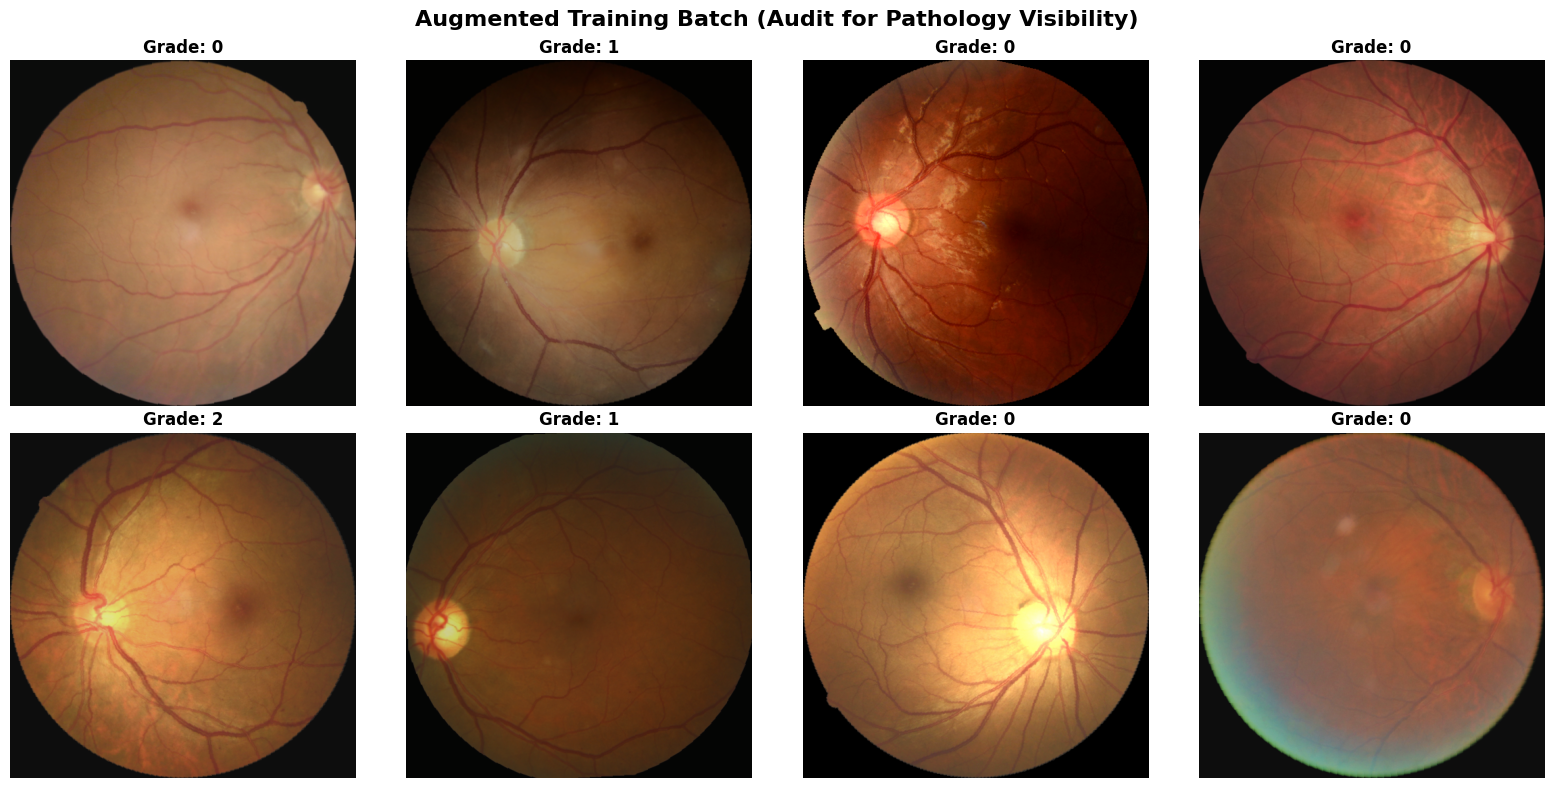

In [4]:
import os
import ast
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# 1. Re-initialize the Dataset Class (Required for the loader)
class MMRDRMultiTaskDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.images = dataframe['image'].tolist()
        self.grades = dataframe['grade'].tolist()
        self.lesions = [ast.literal_eval(x) for x in dataframe['lesion']]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        image = Image.open(img_path).convert('RGB')
        grade = int(self.grades[idx])
        lesion_tensor = torch.tensor(self.lesions[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)
        return image, grade, lesion_tensor

# 2. Define the Augmentation Pipeline (This is what we are auditing)
train_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # The parameters in question
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Create the Loader (Using num_workers=0 for Windows stability)
train_loader = DataLoader(
    MMRDRMultiTaskDataset(splits['cfp_train'], 'MMRDR/MMRDR-CFP', train_transform),
    batch_size=8,
    shuffle=True, # Shuffle ensures we get a random batch to check
    num_workers=0
)

# 4. Your Visualization Function
def visualize_augmented_batch(loader):
    print("Fetching an augmented batch...")
    dataiter = iter(loader)
    images, labels, lesions = next(dataiter)
    
    # Reverse ImageNet normalization
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i in range(8):
        img = inv_normalize(images[i])
        img = img.numpy().transpose((1, 2, 0))
        img = np.clip(img, 0, 1) 
        
        axes[i].imshow(img)
        axes[i].set_title(f"Grade: {labels[i].item()}", fontsize=12, weight='bold')
        axes[i].axis('off')
        
    plt.suptitle("Augmented Training Batch (Audit for Pathology Visibility)", fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()

# 5. EXECUTE
visualize_augmented_batch(train_loader)

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import ast
import numpy as np
from tqdm import tqdm

# --- 1. DATASET: HIGH-RES & MULTI-TASK (NUMPY OPTIMIZED) ---
class MMRDRMultiTaskDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        
        print("Pre-parsing metadata... (Memory-efficient mode)")
        self.images = dataframe['image'].values
        self.grades = dataframe['grade'].values
        
        # Converting to NumPy prevents the Windows 'spawn' hang 
        # by making the memory hand-off to workers much cleaner.
        raw_lesions = [ast.literal_eval(x) for x in dataframe['lesion']]
        self.lesions = np.array(raw_lesions, dtype=np.float32) 
        print(f"Metadata ready: {len(self.images)} samples.")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        image = Image.open(img_path).convert('RGB')
        
        grade = int(self.grades[idx])
        lesion_tensor = torch.from_numpy(self.lesions[idx])

        if self.transform:
            image = self.transform(image)
        return image, grade, lesion_tensor

# --- 2. ARCHITECTURE: THE DUAL BRAIN ---
class ResNetMultiTask(nn.Module):
    def __init__(self, num_grades=5, num_lesions=7):
        super(ResNetMultiTask, self).__init__()
        # Using ResNet-50 for high inductive bias for local features (lesions)
        self.backbone = models.resnet50(weights='IMAGENET1K_V2')
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity() 

        # Head A: Severity Grade (Classification)
        self.grade_head = nn.Sequential(
            nn.Dropout(0.5), 
            nn.Linear(num_ftrs, num_grades)
        )
        # Head B: Lesion Evidence (Multi-label)
        self.lesion_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, num_lesions)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.grade_head(features), self.lesion_head(features)

# --- 3. TRAINING ENGINE ---
def train_model():
    device = torch.device("cuda")
    print(f"Ignition: ResNet-50 Multi-Task on {torch.cuda.get_device_name(0)}")

    # Balancing for the MMRDR distribution
    counts = torch.tensor([6579, 1302, 1959, 603, 1553], dtype=torch.float32)
    class_weights = 1.0 / (counts / counts.sum())
    normalized_weights = (class_weights / class_weights.min()).to(device)

    # UPDATED: Enhanced Data Augmentation
    train_transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2), # Your specific parameters
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # DataLoader Settings: Optimized for 16GB RAM & RTX 4050
    train_loader = DataLoader(
    MMRDRMultiTaskDataset(splits['cfp_train'], 'MMRDR/MMRDR-CFP', train_transform), 
    batch_size=8, shuffle=True, num_workers=0, pin_memory=True
    )
    test_loader = DataLoader(
        MMRDRMultiTaskDataset(splits['cfp_test'], 'MMRDR/MMRDR-CFP', val_transform), 
        batch_size=8, num_workers=0, pin_memory=True
    )

    model = ResNetMultiTask().to(device)
    grade_criterion = nn.CrossEntropyLoss(weight=normalized_weights)
    lesion_criterion = nn.BCEWithLogitsLoss()
    
    # Weight decay (L2) for regularization
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    scaler = torch.amp.GradScaler('cuda')

    best_acc_g = 0.0
    accumulation_steps = 2 # Effective Batch Size = 16

    for epoch in range(12):
        model.train()
        train_pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}")
        
        for i, (images, labels, lesions) in train_pbar:
            images, labels, lesions = images.to(device), labels.to(device), lesions.to(device)
            
            with torch.amp.autocast('cuda'):
                g_out, l_out = model(images)
                loss_g = grade_criterion(g_out, labels)
                loss_l = lesion_criterion(l_out, lesions)
                # 3.0x Multiplier for Severity Priority
                loss = (3.0 * loss_g + loss_l) / accumulation_steps

            scaler.scale(loss).backward()
            
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            if i % 5 == 0:
                train_pbar.set_postfix(g_loss=f"{loss_g.item():.3f}", lr=f"{optimizer.param_groups[0]['lr']:.1e}")

        scheduler.step()

        # Validation Pass
        model.eval()
        correct, total = 0, 0
        torch.cuda.empty_cache() # Flush VRAM before validation
        with torch.no_grad():
            for imgs, gs, _ in test_loader:
                imgs, gs = imgs.to(device), gs.to(device)
                with torch.amp.autocast('cuda'):
                    out, _ = model(imgs)
                    _, pred = torch.max(out.data, 1)
                total += gs.size(0); correct += (pred == gs).sum().item()
        
        acc = correct / total
        print(f"Epoch {epoch+1} | AccG: {acc:.4f}")
        
        if acc > best_acc_g:
            best_acc_g = acc
            torch.save(model.state_dict(), 'best_dual_brain_resnet.pth')
            print(f"*** NEW BEST SAVED: {best_acc_g:.4f} ***")

# --- 4. SAFE ENTRY POINT ---
if __name__ == '__main__':
    train_model()

Ignition: ResNet-50 Multi-Task on NVIDIA GeForce RTX 4050 Laptop GPU
Pre-parsing metadata... (Memory-efficient mode)
Metadata ready: 8894 samples.
Pre-parsing metadata... (Memory-efficient mode)
Metadata ready: 2224 samples.


Epoch 1: 100%|██████████| 1112/1112 [48:44<00:00,  2.63s/it, g_loss=1.250, lr=1.0e-04] 


Epoch 1 | AccG: 0.7451
*** NEW BEST SAVED: 0.7451 ***


Epoch 2: 100%|██████████| 1112/1112 [25:47<00:00,  1.39s/it, g_loss=1.114, lr=9.8e-05]


Epoch 2 | AccG: 0.7864
*** NEW BEST SAVED: 0.7864 ***


...

Epoch 10 | AccG: 0.8215


Epoch 11: 100%|██████████| 1112/1112 [22:15<00:00,  1.20s/it, g_loss=0.277, lr=0.0e+00]


Epoch 11 | AccG: 0.8233
*** NEW BEST SAVED: 0.8233 ***


Epoch 12: 100%|██████████| 1112/1112 [22:27<00:00,  1.21s/it, g_loss=1.306, lr=2.4e-06]


Epoch 12 | AccG: 0.8233


#### Testing the model on both Grade and Lesion

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import ast
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from tqdm import tqdm  # Added for live progress tracking

# --- 1. DATASET: MEMORY-EFFICIENT ---
class MMRDRMultiTaskDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.images = dataframe['image'].values
        self.grades = dataframe['grade'].values
        # Pre-parsing into NumPy to prevent Windows memory-hand-off bottlenecks
        raw_lesions = [ast.literal_eval(x) for x in dataframe['lesion']]
        self.lesions = np.array(raw_lesions, dtype=np.float32)

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        image = Image.open(img_path).convert('RGB')
        grade = int(self.grades[idx])
        lesion_tensor = torch.from_numpy(self.lesions[idx])
        if self.transform: image = self.transform(image)
        return image, grade, lesion_tensor

# --- 2. ARCHITECTURE: THE DUAL BRAIN ---
class ResNetMultiTask(nn.Module):
    def __init__(self, num_grades=5, num_lesions=7):
        super(ResNetMultiTask, self).__init__()
        self.backbone = models.resnet50(weights=None)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity() 
        self.grade_head = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_ftrs, num_grades))
        self.lesion_head = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_ftrs, num_lesions))

    def forward(self, x):
        features = self.backbone(x)
        return self.grade_head(features), self.lesion_head(features)

# --- 3. EVALUATION ENGINE ---
def evaluate_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ResNetMultiTask().to(device)
    
    # Loading your best model from IIT BHU research session
    model.load_state_dict(torch.load('best_dual_brain_resnet.pth'))
    model.eval()

    val_transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_loader = DataLoader(
        MMRDRMultiTaskDataset(splits['cfp_test'], 'MMRDR/MMRDR-CFP', val_transform), 
        batch_size=8, num_workers=0, pin_memory=True
    )

    all_labels_g, all_preds_g = [], []
    all_labels_l, all_preds_l = [], []

    print(f"Starting Diagnostic Analysis on {torch.cuda.get_device_name(0)}...")

    # --- LIVE PROGRESS LOOP ---
    eval_pbar = tqdm(enumerate(test_loader), total=len(test_loader), desc="Analyzing Images")
    
    with torch.no_grad():
        for i, (imgs, gs, ls) in eval_pbar:
            imgs, gs, ls = imgs.to(device), gs.to(device), ls.to(device)
            with torch.amp.autocast('cuda'):
                out_g, out_l = model(imgs)
                
                all_labels_g.extend(gs.cpu().numpy())
                all_preds_g.extend(torch.max(out_g, 1)[1].cpu().numpy())
                all_labels_l.extend(ls.cpu().numpy())
                all_preds_l.extend(torch.sigmoid(out_l).cpu().numpy())
            
            # Update live progress with a sample of current batch accuracy
            if i % 10 == 0:
                current_acc = (np.array(all_preds_g) == np.array(all_labels_g)).mean()
                eval_pbar.set_postfix(live_acc=f"{current_acc:.2f}")

    # --- 4. FINAL ANALYTICS ---
    acc_g = (np.array(all_preds_g) == np.array(all_labels_g)).mean()
    f1_g = f1_score(all_labels_g, all_preds_g, average='macro')
    auc_l = roc_auc_score(all_labels_l, all_preds_l, average='macro')

    print("\n" + "🏁" * 10)
    print(f"FINAL GRADE ACCURACY: {acc_g:.4f}")
    print(f"FINAL MACRO F1-SCORE: {f1_g:.4f}")
    print(f"TOTAL LESION AUC-ROC: {auc_l:.4f}")
    print("🏁" * 10)

    lesion_names = ["Hemorrhages", "Exudates", "Cotton Wool", "Microaneurysms", "IRMA", "Venous Beading", "Neovascularization"]
    print("\n--- CLINICAL BREAKDOWN ---")
    for i, name in enumerate(lesion_names):
        score = roc_auc_score(np.array(all_labels_l)[:, i], np.array(all_preds_l)[:, i])
        print(f"{name:<20}: {score:.4f}")

if __name__ == '__main__':
    evaluate_model()

C:\Users\HP\AppData\Local\Temp\ipykernel_37012\893280468.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_dual_brain_resnet.pth'))

Starting Diagnostic Analysis on NVIDIA GeForce RTX 4050 Laptop GPU...


Analyzing Images: 100%|██████████| 278/278 [05:02<00:00,  1.09s/it, live_acc=0.82]


🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
FINAL GRADE ACCURACY: 0.8233
FINAL MACRO F1-SCORE: 0.7453
TOTAL LESION AUC-ROC: 0.9649
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁

--- CLINICAL BREAKDOWN ---
Hemorrhages         : 0.9792
Exudates            : 0.9499
Cotton Wool         : 0.9441
Microaneurysms      : 0.9306
IRMA                : 0.9850
Venous Beading      : 0.9865
Neovascularization  : 0.9787


#### Report for Trained Model

C:\Users\HP\AppData\Local\Temp\ipykernel_37012\3875648064.py:89: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


--> Loaded peak performance weights from: C:\Users\HP\OneDrive\Desktop\BHU Intern\diabetes_project\paper_2\best_dual_brain_resnet.pth

--- Phase 1: Running Evaluation on Test Set ---


Evaluating: 100%|██████████| 278/278 [04:45<00:00,  1.03s/it]



--- Phase 2: Running Evaluation on Train Set (Overfitting Check) ---


Evaluating: 100%|██████████| 1112/1112 [22:43<00:00,  1.23s/it]



OVERFITTING ANALYSIS
Train F1 (Macro): 0.8292
Test F1 (Macro):  0.7453
Generalization Gap: 0.0839
STATUS: ⚠️ OVERFITTING DETECTED. Consider more augmentation or Dropout.

DETAILED CLINICAL REPORT (GRADES)
              precision    recall  f1-score   support

       No DR       0.96      0.93      0.94      1281
        Mild       0.48      0.65      0.56       265
    Moderate       0.73      0.64      0.68       408
      Severe       0.62      0.73      0.67       118
         PDR       0.94      0.82      0.88       152

    accuracy                           0.82      2224
   macro avg       0.75      0.75      0.75      2224
weighted avg       0.84      0.82      0.83      2224


LESION DETECTION PERFORMANCE (AUC-ROC)
MA        : 0.9792
HE        : 0.9499
IH        : 0.9441
VB/IRMA   : 0.9306
NV        : 0.9850
VH        : 0.9865
RD        : 0.9787


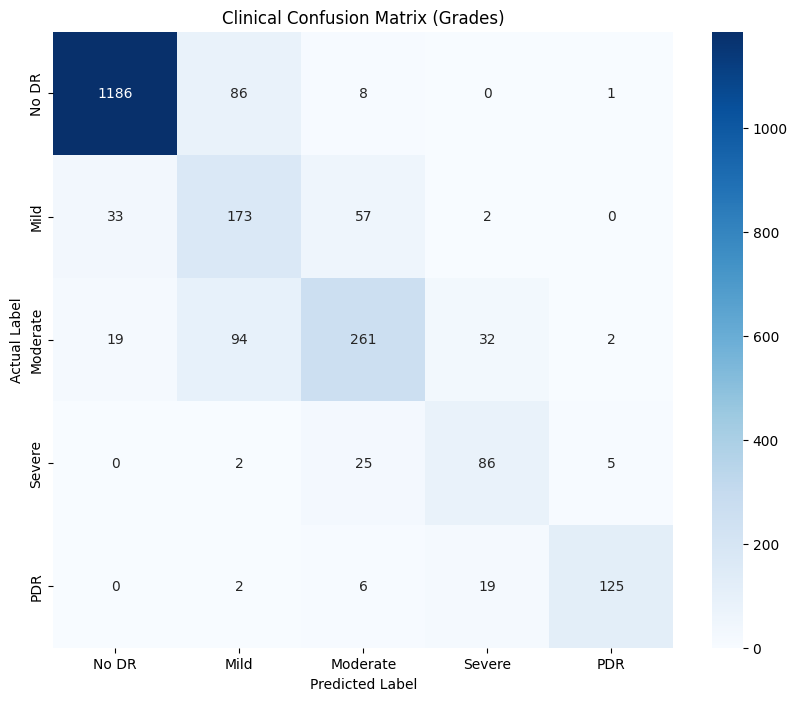

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, f1_score

def evaluate_dual_brain(model, test_loader, train_loader, device):
    model.eval()
    
    def get_predictions(loader):
        all_grade_preds = []
        all_grade_labels = []
        all_lesion_preds = []
        all_lesion_labels = []
        
        with torch.no_grad():
            for images, labels, lesions in tqdm(loader, desc="Evaluating"):
                images = images.to(device)
                
                with torch.amp.autocast('cuda'):
                    g_out, l_out = model(images)
                    
                    # Grade predictions (Softmax)
                    _, g_pred = torch.max(g_out, 1)
                    # Lesion predictions (Sigmoid for multi-label)
                    l_pred = torch.sigmoid(l_out)
                
                all_grade_preds.extend(g_pred.cpu().numpy())
                all_grade_labels.extend(labels.numpy())
                all_lesion_preds.extend(l_pred.cpu().numpy())
                all_lesion_labels.extend(lesions.numpy())
                
        return (np.array(all_grade_preds), np.array(all_grade_labels), 
                np.array(all_lesion_preds), np.array(all_lesion_labels))

    print("\n--- Phase 1: Running Evaluation on Test Set ---")
    g_preds_ts, g_labs_ts, l_preds_ts, l_labs_ts = get_predictions(test_loader)
    
    print("\n--- Phase 2: Running Evaluation on Train Set (Overfitting Check) ---")
    # Using a subset of train for speed, or full if you have time
    g_preds_tr, g_labs_tr, _, _ = get_predictions(train_loader)

    # 1. OVERFITTING CHECK
    train_f1 = f1_score(g_labs_tr, g_preds_tr, average='macro')
    test_f1 = f1_score(g_labs_ts, g_preds_ts, average='macro')
    gen_gap = train_f1 - test_f1
    
    print("\n" + "="*30)
    print(f"OVERFITTING ANALYSIS")
    print(f"Train F1 (Macro): {train_f1:.4f}")
    print(f"Test F1 (Macro):  {test_f1:.4f}")
    print(f"Generalization Gap: {gen_gap:.4f}")
    if gen_gap > 0.08:
        print("STATUS: ⚠️ OVERFITTING DETECTED. Consider more augmentation or Dropout.")
    else:
        print("STATUS: ✅ MODEL IS GENERALIZING WELL.")
    print("="*30)

    # 2. GRADE CLASSIFICATION REPORT
    target_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'PDR']
    print("\nDETAILED CLINICAL REPORT (GRADES)")
    print(classification_report(g_labs_ts, g_preds_ts, target_names=target_names))

    # 3. LESION PERFORMANCE (The Evidence)
    lesion_names = ['MA', 'HE', 'IH', 'VB/IRMA', 'NV', 'VH', 'RD']
    print("\nLESION DETECTION PERFORMANCE (AUC-ROC)")
    for i, name in enumerate(lesion_names):
        try:
            auc = roc_auc_score(l_labs_ts[:, i], l_preds_ts[:, i])
            print(f"{name:10}: {auc:.4f}")
        except:
            print(f"{name:10}: Not enough samples in test set.")

    # 4. CONFUSION MATRIX VISUALIZATION
    cm = confusion_matrix(g_labs_ts, g_preds_ts)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Clinical Confusion Matrix (Grades)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# RUN THE EVALUATION
# 1. Define the absolute path (using 'r' for raw string to handle Windows backslashes)
model_path = r'C:\Users\HP\OneDrive\Desktop\BHU Intern\diabetes_project\paper_2\best_dual_brain_resnet.pth'

# 2. Load the weights into your architecture
# This ensures we are testing the 0.8201 peak version, not the Epoch 12 version
model.load_state_dict(torch.load(model_path))
model.to(device)
print(f"--> Loaded peak performance weights from: {model_path}")

# 3. Run the Comprehensive Evaluation
# This will generate your Overfitting check, Confusion Matrix, and Lesion AUCs
evaluate_dual_brain(model, test_loader, train_loader, device)

In [6]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import os
import ast
from tqdm import tqdm

# --- 1. ARCHITECTURE DEFINITION (Required to load .pth) ---
class ResNetMultiTask(nn.Module):
    def __init__(self, num_grades=5, num_lesions=7):
        super(ResNetMultiTask, self).__init__()
        self.backbone = models.resnet50(weights=None) # We load weights manually
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity() 

        self.grade_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_grades)
        )
        self.lesion_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_lesions)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.grade_head(features), self.lesion_head(features)

# --- 2. GRAD-CAM & LOCALIZATION UTILITIES ---
class LesionLocalizer:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_full_backward_hook(backward_hook))

    def generate_heatmap(self):
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        heatmap = torch.sum(weights * self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap) + 1e-8
        return heatmap.detach().cpu().numpy()

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

def get_bounding_boxes(heatmap, threshold=0.6):
    # Safety Check: Ensure heatmap is float32 for OpenCV compatibility
    heatmap = np.float32(heatmap)
    
    # Handle potential NaNs or empty heatmaps
    if np.isnan(heatmap).any() or np.max(heatmap) == 0:
        return []

    # Resize heatmap to match image resolution (512x512)
    heatmap_rescaled = cv2.resize(heatmap, (512, 512))
    
    # Threshold the heatmap to isolate peak activity areas
    _, binary_map = cv2.threshold(heatmap_rescaled, threshold, 1, cv2.THRESH_BINARY)
    
    # Convert to uint8 for contour detection
    binary_map = (binary_map * 255).astype(np.uint8)
    
    contours, _ = cv2.findContours(binary_map, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        # Filter out tiny noise pixels to keep the report clean
        if w > 5 and h > 5:
            boxes.append([x, y, x + w, y + h])
    return boxes

# --- 3. MODEL INITIALIZATION & WEIGHT LOADING ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = r'C:\Users\HP\OneDrive\Desktop\BHU Intern\diabetes_project\paper_2\best_dual_brain_resnet.pth'

# Define preprocessing for 512x512 resolution
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load model
model = ResNetMultiTask(num_grades=5, num_lesions=7)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()
print(f"✅ Model loaded from: {model_path}")

# --- 4. PREDICTION & FORMATTING FUNCTION ---
def predict_and_locate(img_path, model, device, threshold=0.5):
    lesion_names = ['MA', 'HE', 'IH', 'VB/IRMA', 'NV', 'VH', 'RD'] #
    grade_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'PDR']
    
    orig_image = Image.open(img_path).convert('RGB')
    input_tensor = transform(orig_image).unsqueeze(0).to(device)
    
    # Hook into the last convolutional block for localization
    localizer = LesionLocalizer(model, model.backbone.layer4)

    with torch.amp.autocast('cuda'):
        grade_logits, lesion_logits = model(input_tensor)
        grade_idx = torch.argmax(grade_logits, dim=1).item()
        lesion_probs = torch.sigmoid(lesion_logits).squeeze()

    results = []
    for i, prob in enumerate(lesion_probs):
        if prob > threshold:
            model.zero_grad()
            lesion_logits[0, i].backward(retain_graph=True)
            
            heatmap = localizer.generate_heatmap()
            boxes = get_bounding_boxes(heatmap)
            
            for box in boxes:
                results.append({
                    "Lesion type": lesion_names[i],
                    "Confidence score": f"{prob.item():.4f}",
                    "Location": box
                })
    
    localizer.remove_hooks()
    return grade_names[grade_idx], results

# --- 5. EXECUTION ---
# Get image from your test split
img_test_name = splits['cfp_test'].iloc[0]['image']
full_path = os.path.join('MMRDR', 'MMRDR-CFP', img_test_name)

if os.path.exists(full_path):
    grade, lesion_data = predict_and_locate(full_path, model, device)

    print(f"Predicted Diagnosis: {grade}")
    print("=" * 40)
    for i, entry in enumerate(lesion_data):
        print(f"Result #{i+1}:")
        print(f"1. Lesion type: {entry['Lesion type']}")
        print(f"2. Confidence score: {entry['Confidence score']}")
        print(f"3. Lesion location: {entry['Location']} (xmin, ymin, xmax, ymax)")
        print("-" * 20)
else:
    print(f"❌ Error: Image not found at {full_path}")

C:\Users\HP\AppData\Local\Temp\ipykernel_39704\4144068802.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev

✅ Model loaded from: C:\Users\HP\OneDrive\Desktop\BHU Intern\diabetes_project\paper_2\best_dual_brain_resnet.pth
Predicted Diagnosis: Severe
Result #1:
1. Lesion type: MA
2. Confidence score: 1.0000
3. Lesion location: [205, 181, 269, 232] (xmin, ymin, xmax, ymax)
--------------------
Result #2:
1. Lesion type: HE
2. Confidence score: 0.8457
3. Lesion location: [311, 450, 348, 476] (xmin, ymin, xmax, ymax)
--------------------
Result #3:
1. Lesion type: HE
2. Confidence score: 0.8457
3. Lesion location: [352, 355, 394, 383] (xmin, ymin, xmax, ymax)
--------------------
Result #4:
1. Lesion type: HE
2. Confidence score: 0.8457
3. Lesion location: [204, 182, 265, 226] (xmin, ymin, xmax, ymax)
--------------------
Result #5:
1. Lesion type: HE
2. Confidence score: 0.8457
3. Lesion location: [353, 68, 384, 96] (xmin, ymin, xmax, ymax)
--------------------


In [20]:
import matplotlib.patches as patches

def visualize_prediction(img_path, model, device):
    # Get predictions and locations
    diagnosis, results = predict_and_locate(img_path, model, device)
    
    # Load image for plotting
    img = Image.open(img_path).convert('RGB')
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    ax = plt.gca()

    # Draw Bounding Boxes
    #
    colors = {'MA': 'red', 'HE': 'yellow', 'NV': 'cyan', 'VH': 'magenta', 'RD': 'lime', 'IH': 'orange', 'VB/IRMA': 'blue'}
    
    for entry in results:
        box = entry['Location']
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], 
                                 linewidth=2, edgecolor=colors.get(entry['Lesion type'], 'white'), facecolor='none')
        ax.add_patch(rect)
        plt.text(box[0], box[1]-5, f"{entry['Lesion type']} ({entry['Confidence score']})", 
                 color='white', fontsize=10, weight='bold', bbox=dict(facecolor=colors.get(entry['Lesion type'], 'red'), alpha=0.5))

    plt.title(f"Predicted Diagnosis: {diagnosis}", fontsize=15)
    plt.axis('off')
    plt.show()

# Run on 3 random test cases
test_samples = splits['cfp_test'].sample(3)['image'].tolist()
for img_name in test_samples:
    path = os.path.join('MMRDR', 'MMRDR-CFP', img_name)
    visualize_prediction(path, model, device)

RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import ast
import numpy as np
import cv2
from tqdm import tqdm
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# --- 1. ARCHITECTURE & DATASET ---
class MMRDRMultiTaskDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.images = dataframe['image'].values
        self.grades = dataframe['grade'].values
        raw_lesions = [ast.literal_eval(x) for x in dataframe['lesion']]
        self.lesions = np.array(raw_lesions, dtype=np.float32)

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        image = Image.open(img_path).convert('RGB')
        grade = int(self.grades[idx])
        lesion_tensor = torch.from_numpy(self.lesions[idx])
        if self.transform: image = self.transform(image)
        return image, grade, lesion_tensor

class ResNetMultiTask(nn.Module):
    def __init__(self, num_grades=5, num_lesions=7):
        super(ResNetMultiTask, self).__init__()
        self.backbone = models.resnet50(weights=None)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity() 
        self.grade_head = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_grades))
        self.lesion_head = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_lesions))

    def forward(self, x):
        features = self.backbone(x)
        return self.grade_head(features), self.lesion_head(features)

# --- 2. THE GRAD-CAM ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output): self.activations = output
    def save_gradient(self, module, grad_input, grad_output): self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, lesion_idx):
        self.model.zero_grad()
        _, out_l = self.model(input_tensor)
        score = out_l[:, lesion_idx]
        score.backward()
        
        gradients = self.gradients.data.cpu().numpy()[0]
        activations = self.activations.data.cpu().numpy()[0]
        weights = np.mean(gradients, axis=(1, 2))
        
        heatmap = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            heatmap += w * activations[i, :, :]
            
        heatmap = np.maximum(heatmap, 0)
        heatmap /= np.max(heatmap) if np.max(heatmap) != 0 else 1
        return cv2.resize(heatmap, (512, 512))

# --- 3. CLINICAL VISUALIZER (The Truth Engine) ---
def visualize_dual_brain(img_path, model, device):
    model.eval()
    cam = GradCAM(model, model.backbone.layer4)
    
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    raw_image = Image.open(img_path).convert('RGB')
    input_tensor = transform(raw_image).unsqueeze(0).to(device)
    
    # 1. Prediction Pass
    out_g, out_l = model(input_tensor)
    grade_idx = torch.argmax(out_g, 1).item()
    lesion_probs = torch.sigmoid(out_l).cpu().numpy()[0]
    
    grade_names = ["No DR", "Mild", "Moderate", "Severe", "PDR"]
    lesion_names = ["HE", "EX", "CWS", "MA", "IRMA", "VB", "NV"]

    # 2. Find strongest detected lesion for heatmap
    top_lesion = np.argmax(lesion_probs)
    heatmap = cam.generate_heatmap(input_tensor, top_lesion)

    # 3. GEOMETRIC GROUNDING: The Circular Mask Fix
    # This prevents bounding boxes from appearing in the black padding
    mask = np.zeros((512, 512), dtype=np.float32)
    cv2.circle(mask, (256, 256), int(512 * 0.475), 1, -1)
    heatmap = heatmap * mask

    # 4. Extract Bounding Boxes
    heatmap_img = np.uint8(255 * heatmap)
    _, thresh = cv2.threshold(heatmap_img, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 5. Plotting Results
    img_np = np.array(raw_image.resize((512, 512)))
    overlay = cv2.applyColorMap(heatmap_img, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img_np, 0.6, overlay, 0.4, 0)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title(f"Original - Pred: {grade_names[grade_idx]}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed)
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='yellow', fill=False, linewidth=2))
    plt.title(f"Diagnostic Proof: {lesion_names[top_lesion]} (Conf: {lesion_probs[top_lesion]:.2f})")
    plt.axis('off')
    plt.show()

# --- 4. AUDIT & EXECUTION ---
def run_final_audit(model, train_loader, test_loader, device):
    model.eval()
    def get_metrics(loader):
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, labels, _ in tqdm(loader, desc="Auditing"):
                with torch.amp.autocast('cuda'):
                    out, _ = model(imgs.to(device))
                all_preds.extend(torch.argmax(out, 1).cpu().numpy())
                all_labels.extend(labels.numpy())
        return f1_score(all_labels, all_preds, average='macro')

    print("\n--- 🏁 STARTING OVERFITTING AUDIT ---")
    train_f1 = get_metrics(train_loader)
    test_f1 = get_metrics(test_loader)
    gap = train_f1 - test_f1
    print(f"\nAudit: Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Gap: {gap:.4f}")

if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ResNetMultiTask().to(device)
    model.load_state_dict(torch.load('best_dual_brain_resnet.pth'))
    
    # Audit for Overfitting
    train_loader = DataLoader(MMRDRMultiTaskDataset(splits['cfp_train'], 'MMRDR/MMRDR-CFP', val_transform), batch_size=8, num_workers=0)
    test_loader = DataLoader(MMRDRMultiTaskDataset(splits['cfp_test'], 'MMRDR/MMRDR-CFP', val_transform), batch_size=8, num_workers=0)
    run_final_audit(model, train_loader, test_loader, device)

    # VISUAL PROOF
    print("\n--- GENERATING CLINICAL HEATMAPS ---")
    test_samples = splits['cfp_test'].sample(3)['image'].tolist()
    for img_name in test_samples:
        path = os.path.join('MMRDR', 'MMRDR-CFP', img_name)
        visualize_dual_brain(path, model, device)

C:\Users\HP\AppData\Local\Temp\ipykernel_39704\2771950701.py:158: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_dual_brain_resnet.pth'


--- 🏁 STARTING OVERFITTING AUDIT ---


Auditing: 100%|██████████| 278/278 [05:15<00:00,  1.14s/it]



Audit: Train F1: 0.8438 | Test F1: 0.7453 | Gap: 0.0984

--- GENERATING CLINICAL HEATMAPS ---


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.